----
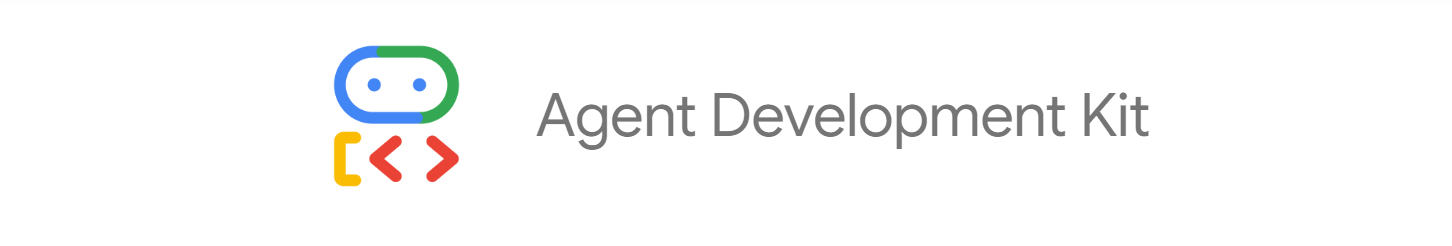

---

# Deploy to Cloud Run using gcloud-CLI

## Deployment commands
### Python gcloud-CLI
#### **`gcloud CLI for Python`**
Alternatively, you can deploy using the standard `gcloud run` `deploy` command with a `Dockerfile`. This method requires more manual setup compared to the adk command but offers flexibility, particularly if you want to embed your agent within a custom [FastAPI](https://fastapi.tiangolo.com/) application.

Ensure you have authenticated with Google Cloud (`gcloud auth login` and `gcloud config set project <your-project-id>`).

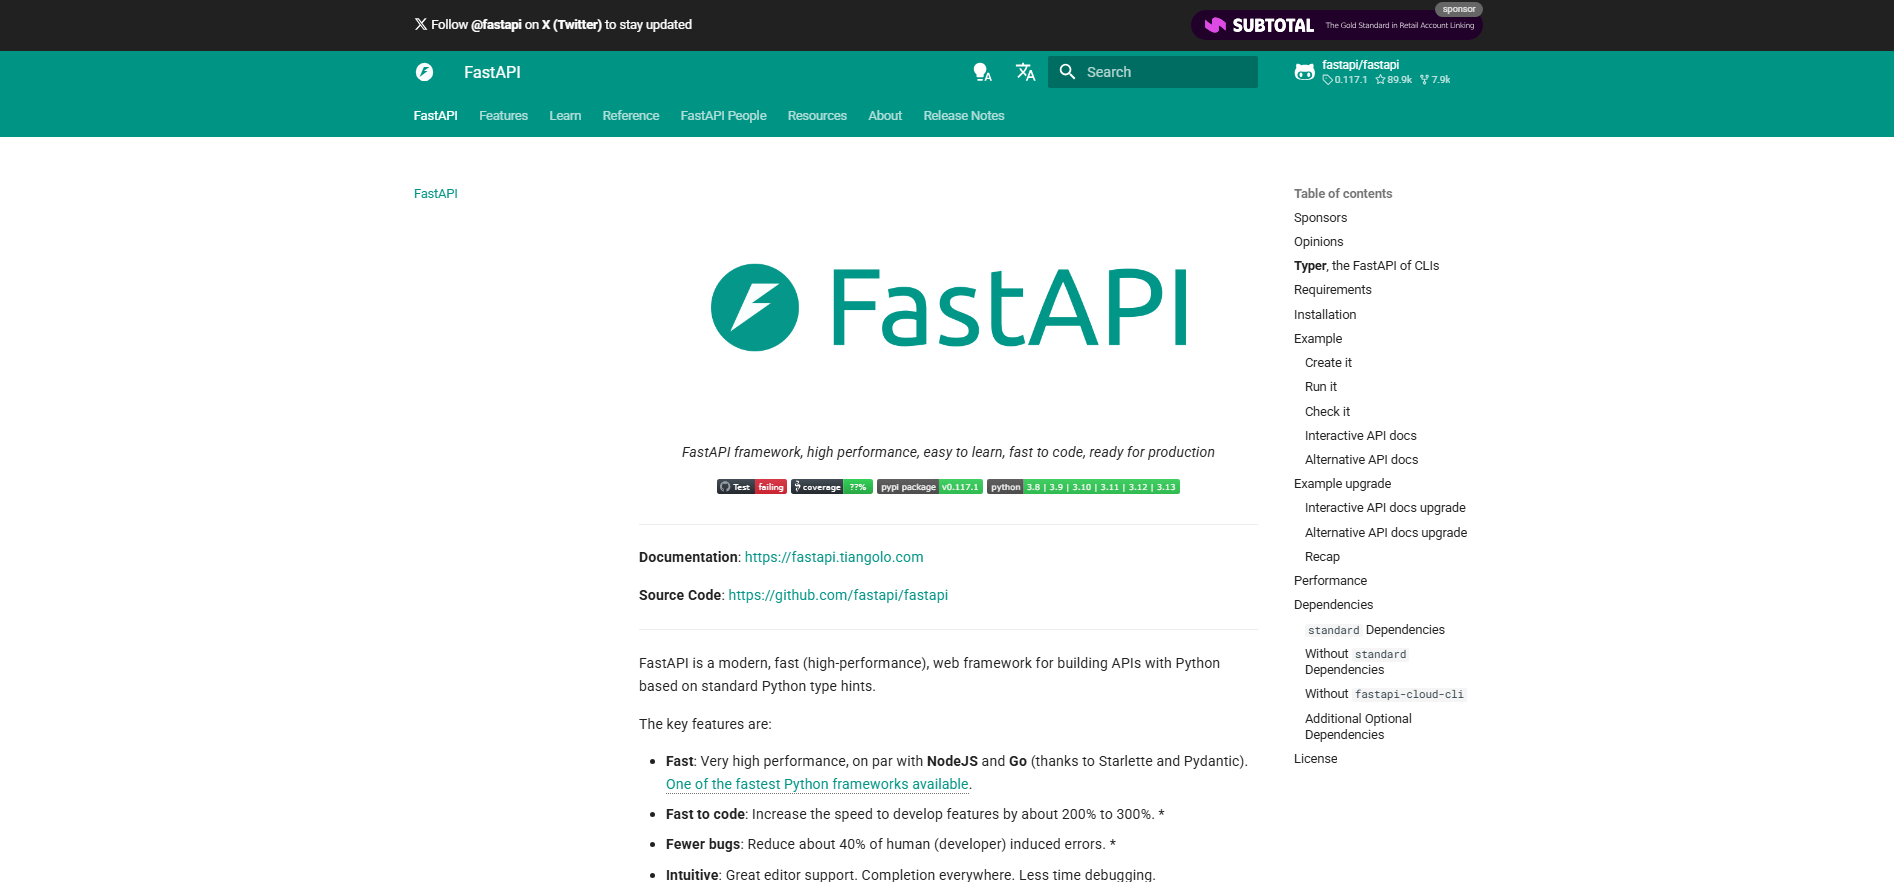

**Project Structure**

Organize your project files as follows:

```
your-project-directory/
├── capital_agent/
│   ├── __init__.py
│   └── agent.py       # Your agent code (see "Agent sample" tab)
├── main.py            # FastAPI application entry point
├── requirements.txt   # Python dependencies
└── Dockerfile         # Container build instructions
```

Create the following files (`main.py`, `requirements.txt`, `Dockerfile`) in the root of `your-project-directory/`.

#### **`Code files`**

1. This file sets up the FastAPI application using `get_fast_api_app()` from ADK:

#### **main.py**
```Python
import os

import uvicorn
from fastapi import FastAPI
from google.adk.cli.fast_api import get_fast_api_app

# Get the directory where main.py is located
AGENT_DIR = os.path.dirname(os.path.abspath(__file__))
# Example session service URI (e.g., SQLite)
SESSION_SERVICE_URI = "sqlite:///./sessions.db"
# Example allowed origins for CORS
ALLOWED_ORIGINS = ["http://localhost", "http://localhost:8080", "*"]
# Set web=True if you intend to serve a web interface, False otherwise
SERVE_WEB_INTERFACE = True

# Call the function to get the FastAPI app instance
# Ensure the agent directory name ('capital_agent') matches your agent folder
app: FastAPI = get_fast_api_app(
    agents_dir=AGENT_DIR,
    session_service_uri=SESSION_SERVICE_URI,
    allow_origins=ALLOWED_ORIGINS,
    web=SERVE_WEB_INTERFACE,
)

# You can add more FastAPI routes or configurations below if needed
# Example:
# @app.get("/hello")
# async def read_root():
#     return {"Hello": "World"}

if __name__ == "__main__":
    # Use the PORT environment variable provided by Cloud Run, defaulting to 8080
    uvicorn.run(app, host="0.0.0.0", port=int(os.environ.get("PORT", 8080)))
```

> Note: We specify `agent_dir` to the directory `main.py` is in and use `os.environ.get("PORT", 8080)` for Cloud Run compatibility.

----

2. List the necessary Python packages:

#### `requirements.txt`
```Python
google-adk
# Add any other dependencies your agent needs
```

----

3. Define the container image:
#### **Dockerfile**
```bash
FROM python:3.13-slim
WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

RUN adduser --disabled-password --gecos "" myuser && \
    chown -R myuser:myuser /app

COPY . .

USER myuser

ENV PATH="/home/myuser/.local/bin:$PATH"

CMD ["sh", "-c", "uvicorn main:app --host 0.0.0.0 --port $PORT"]
```

---

### Defining Multiple Agents
You can define and deploy multiple agents within the same Cloud Run instance by creating separate folders in the root of `your-project-directory/`. Each folder represents one agent and must define a `root_agent` in its configuration.

**Example structure:**

```
your-project-directory/
├── capital_agent/
│   ├── __init__.py
│   └── agent.py       # contains `root_agent` definition
├── population_agent/
│   ├── __init__.py
│   └── agent.py       # contains `root_agent` definition
└── ...
```

---
### Deploy using `gcloud``
```bash
Navigate to `your-project-directory` in your terminal.
gcloud run deploy capital-agent-service \
--source . \
--region $GOOGLE_CLOUD_LOCATION \
--project $GOOGLE_CLOUD_PROJECT \
--allow-unauthenticated \
--set-env-vars="GOOGLE_CLOUD_PROJECT=$GOOGLE_CLOUD_PROJECT,GOOGLE_CLOUD_LOCATION=$GOOGLE_CLOUD_LOCATION,GOOGLE_GENAI_USE_VERTEXAI=$GOOGLE_GENAI_USE_VERTEXAI"
# Add any other necessary environment variables your agent might need
```

----

- `capital-agent-service`: The name you want to give your Cloud Run service.
- `--source .`: Tells gcloud to build the container image from the Dockerfile in the current directory.
- `--region`: Specifies the deployment region.
- `--project`: Specifies the GCP project.
- `--allow-unauthenticated:` Allows public access to the service. Remove this flag for private services.
- `--set-env-vars`: Passes necessary environment variables to the running container. Ensure you include all variables required by ADK and your agent (like API keys if not using Application Default Credentials).

`gcloud` will build the Docker image, push it to Google Artifact Registry, and deploy it to Cloud Run. Upon completion, it will output the URL of your deployed service.

For a full list of deployment options, see the [gcloud run deploy reference documentation](https://cloud.google.com/sdk/gcloud/reference/run/deploy).

#### `gcloud run deploy`
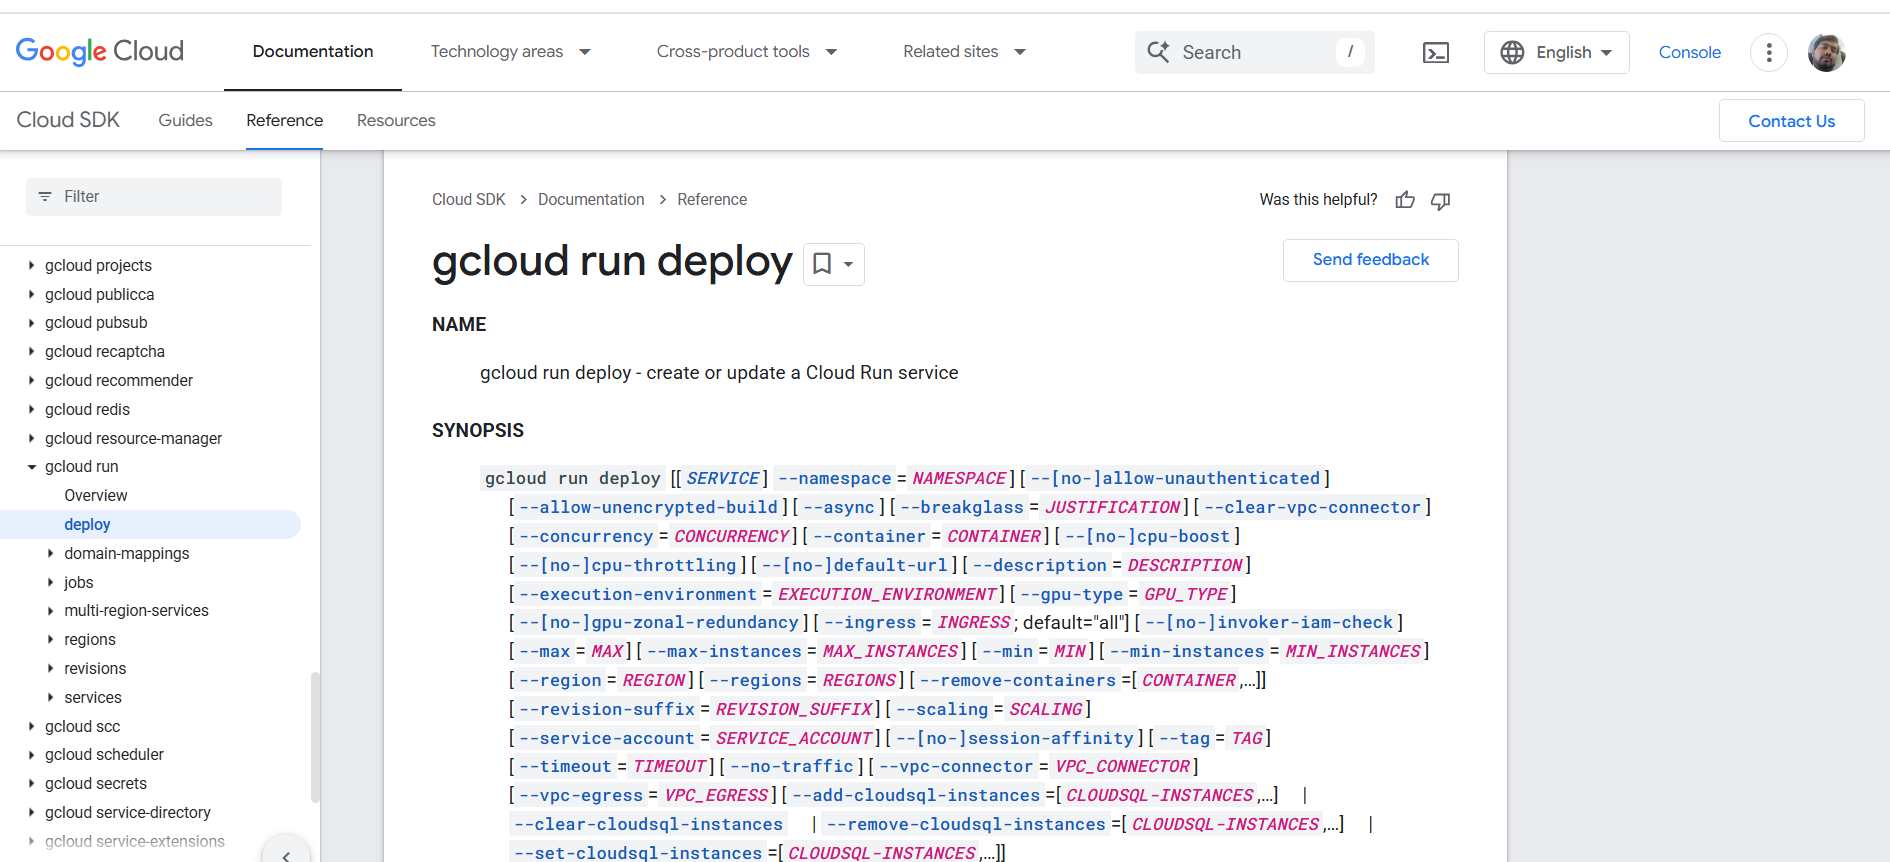

----

## Testing your agent
Once your agent is deployed to Cloud Run, you can interact with it via the deployed UI (if enabled) or directly with its API endpoints using tools like `curl`. You'll need the service URL provided after deployment.

### **`UI Testing`**
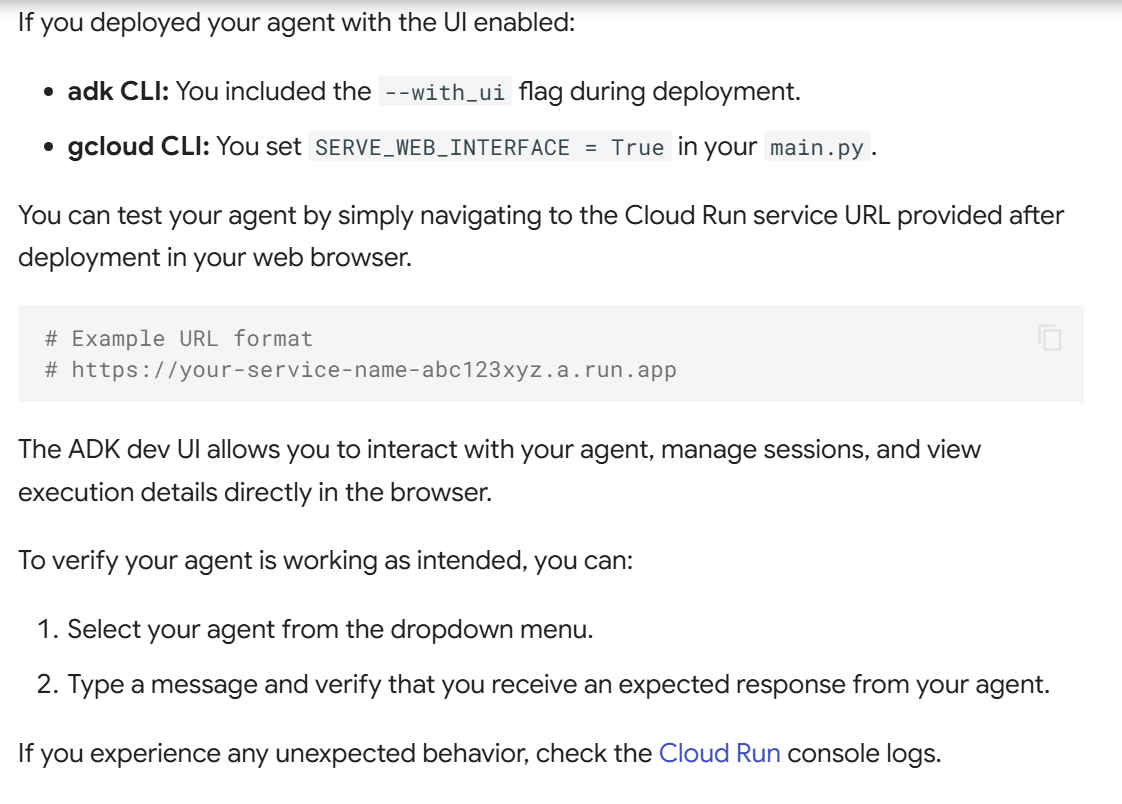

### **`API Testing (curl)`**
You can interact with the agent's API endpoints using tools like curl. This is useful for programmatic interaction or if you deployed without the UI.

You'll need the service URL provided after deployment and potentially an identity token for authentication if your service isn't set to allow unauthenticated access.

**Set the application URL**

Replace the example URL with the actual URL of your deployed Cloud Run service.
```Python
export APP_URL="YOUR_CLOUD_RUN_SERVICE_URL"
# Example: export APP_URL="https://adk-default-service-name-abc123xyz.a.run.app"
```

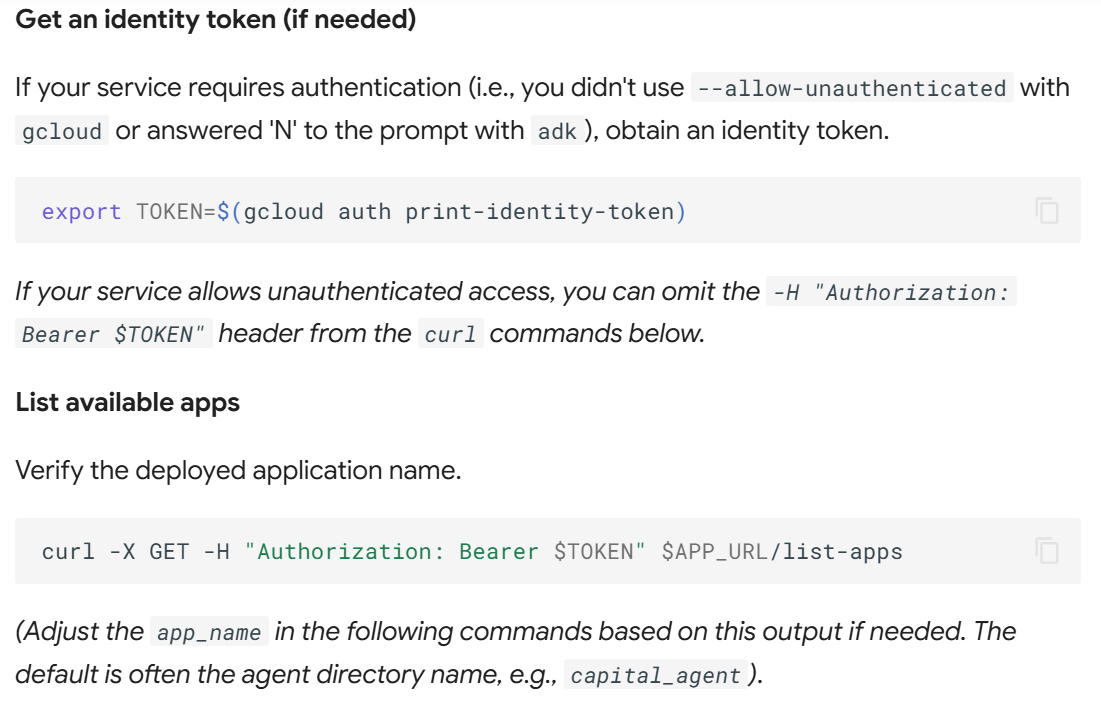 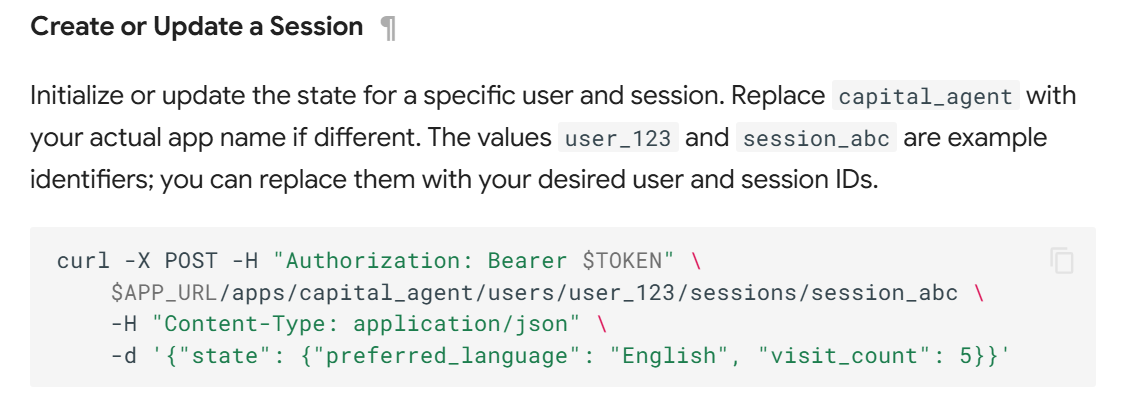 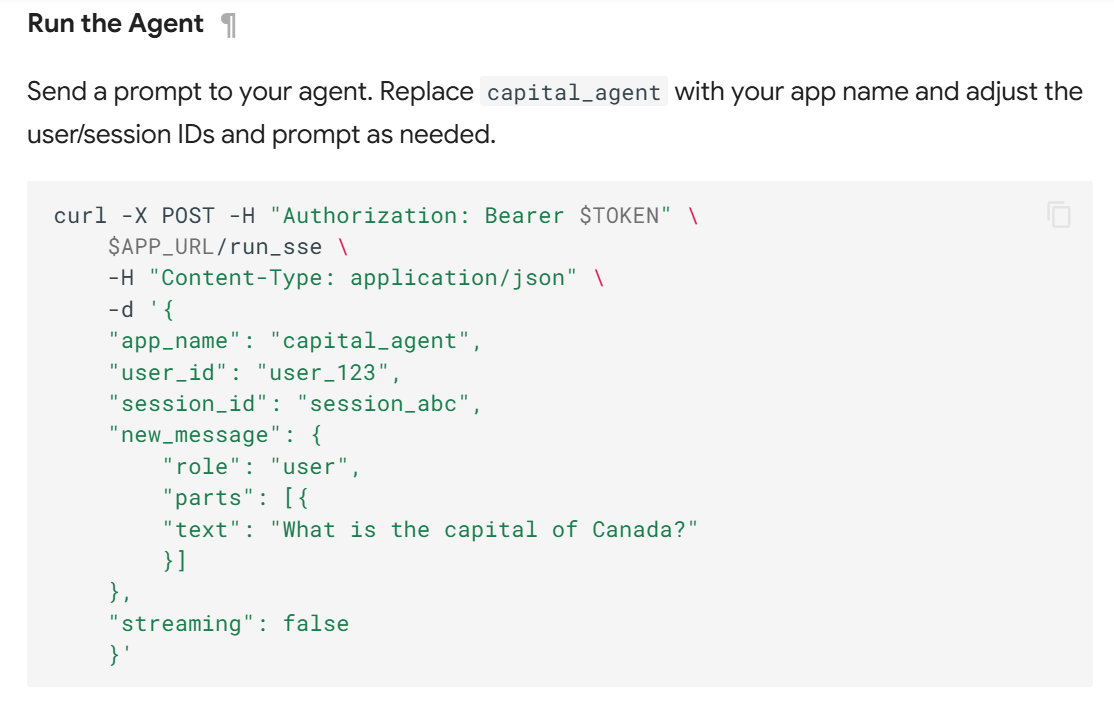 

- Set `"streaming": true` if you want to receive Server-Sent Events (SSE).
- The response will contain the agent's execution events, including the final answer.

---